# Boosting para proyecto diabetes  

#### Este notebook explora el dataset Diabetes utilizando algoritmos boosting, complementando los estudios previos realizados con árboles de decisión y bosques aleatorios. A través de un EDA unificado, buscamos demostrar cómo la variación en las metodologías y modelos seleccionados transforma las conclusiones analíticas, validando así distintas estrategias desde un punto de partida común.

De acuerdo con los lineamientos de esta etapa, basaremos la evaluación del desempeño del algoritmo en el indicador de accuracy, garantizando así la fiabilidad de nuestras predicciones 

A efectos de este proyecto, utilizaremos la métrica de accuracy para cuantificar la exactitud del modelo. Esta indicará cuántas predicciones resultaron acertadas (ya sea positivo o negativo para diabetes) sobre el conjunto total de la población evaluada.

In [280]:
import sys
print(sys.executable)

c:\Users\User\anaconda3\envs\demohealth\python.exe


In [281]:
import sys
!{sys.executable} -m pip install xgboost

In [282]:
from xgboost import XGBClassifier
print("XGBoost OK")

XGBoost OK


In [283]:
# importación de librerías

import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carga de los datos procesados en las etapas anteroires.
# Aquí cargamos los conjuntos de datos ya procesados:
# - X_train y X_test contienen las variables explicativas para entrenamiento y prueba.
# - y_train y y_test contienen la variable objetivo (diabetes sí/no) para train y test.

X_train = pd.read_csv("data/raw/X_train_procesado.csv")
X_test  = pd.read_csv("data/raw/X_test_procesado.csv")
y_train = pd.read_csv("data/raw/y_train_procesado.csv").squeeze()
y_test  = pd.read_csv("data/raw/y_test_procesado.csv").squeeze()



print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(614, 6) (154, 6) (614,) (154,)


Dado que la métrica de accuracy es muy sensible frente a clases desbalanceadas, a continuación se presenta un gráfico de la variable objetivo en el conjunto de entrenamiento para evaluar la magnitud de dicho desbalance

--- Conteo total por clase en y_train ---
Outcome
0    400
1    214
Name: count, dtype: int64


--- Porcentaje de cada clase en y_train (%) ---
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64


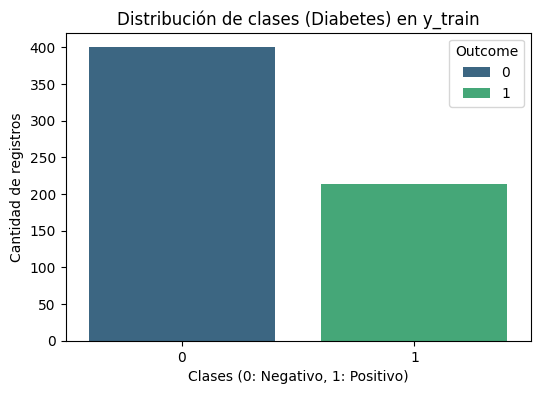

In [285]:

# Aseguramos que y_train sea una Serie (por si no se ha ejecutado la celda de aplanamiento)
y_target = y_train.iloc[:, 0] if isinstance(y_train, pd.DataFrame) else y_train

# Conteo absoluto de cada clase en entrenamiento
conteo = y_target.value_counts()
print("--- Conteo total por clase en y_train ---")
print(conteo)
print("\n")

# Porcentaje de representación (nivel de desbalance)
porcentaje = y_target.value_counts(normalize=True) * 100
print("--- Porcentaje de cada clase en y_train (%) ---")
print(porcentaje.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_target, hue=y_target, palette='viridis')
plt.title('Distribución de clases (Diabetes) en y_train')
plt.ylabel('Cantidad de registros')
plt.xlabel('Clases (0: Negativo, 1: Positivo)')
plt.show()

Dado que la proporción de 66 % frente a 34 % representa un desbalance manejable, esto no supondrá un problema significativo para la robustez de los algoritmos de boosting seleccionados para esta etapa del proyecto.

### GradientBoostingClassifier

In [286]:
# Entrenamiento y evaluación del Gradient Boosting base
# En esta celda creamos un modelo GradientBoostingClassifier con parámetros por defecto.
# Entrenamos el modelo con X_train e y_train para que aprenda a predecir la diabetes.
# Luego predecimos sobre X_test y calculamos accuracy, precision, recall y F1 en el conjunto de prueba.
# Estas métricas nos dan un rendimiento de referencia del boosting antes de ajustar hiperparámetros.
gbc_base = GradientBoostingClassifier(random_state=42)
gbc_base.fit(X_train, y_train.values)

y_pred_base = gbc_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, average="binary")
rec_base = recall_score(y_test, y_pred_base, average="binary")
f1_base = f1_score(y_test, y_pred_base, average="binary")

print("GradientBoosting (base)")
print("Accuracy:", acc_base)
print("Precision:", prec_base)
print("Recall:", rec_base)
print("F1:", f1_base)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_base))

print("\nMatriz de confusión:")
cm_base = confusion_matrix(y_test, y_pred_base)
print(cm_base)

GradientBoosting (base)
Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112
F1: 0.6346153846153846

Classification report:

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Matriz de confusión:
[[83 17]
 [21 33]]


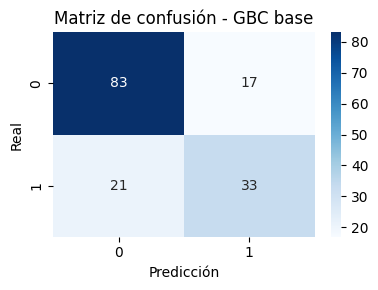

In [287]:
# Aquí representamos la matriz de confusión del modelo base como un mapa de calor.

plt.figure(figsize=(4, 3))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - GBC base")
plt.tight_layout()
plt.show()

In [288]:
# Definición de la rejilla de hiperparámetros
# En esta celda definimos una pequeña rejilla de hiperparámetros para probar varios modelos.
# Probamos distintas combinaciones de:
# - n_estimators: número de árboles en el ensemble.
# - learning_rate: tamaño del paso de actualización en cada iteración.
# - max_depth: profundidad máxima de los árboles base.
# Esta lista servirá para hacer un pequeño experimento de tuning manual.
resultados = []

param_grid = [
    {"n_estimators": 50,  "learning_rate": 0.1, "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3},
    {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 2},
]

In [289]:
# Entrenamiento de varios modelos y recopilación de métricas
# Aquí recorremos cada combinación de param_grid y entrenamos un modelo de Gradient Boosting.
# Para cada modelo:
# - Lo ajustamos con X_train e y_train.
# - Predecimos sobre X_test.
# - Calculamos accuracy, precision, recall y F1 en test.
# Guardamos hiperparámetros y métricas en una lista de diccionarios.
# Al final construiremos un DataFrame con todos estos resultados para compararlos.
for params in param_grid:
    gbc = GradientBoostingClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        random_state=42
    )
    gbc.fit(X_train, y_train.values.ravel())
    y_pred = gbc.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="binary")
    rec = recall_score(y_test, y_pred, average="binary")
    f1 = f1_score(y_test, y_pred, average="binary")

    resultados.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados);

   n_estimators  learning_rate  max_depth  accuracy  precision    recall  \
0            50           0.10          3  0.746753   0.653061  0.592593   
1           100           0.10          3  0.753247   0.660000  0.611111   
2           200           0.10          3  0.772727   0.693878  0.629630   
3           100           0.05          3  0.746753   0.653061  0.592593   
4           100           0.10          2  0.746753   0.653061  0.592593   

         f1  
0  0.621359  
1  0.634615  
2  0.660194  
3  0.621359  
4  0.621359  


In [290]:
# Ordenar resultados y ver la tabla por Accuracy
# En esta celda ordenamos el DataFrame de resultados por la métrica Accuracy de mayor a menor.
# Esto nos permite identificar rápidamente qué combinación de hiperparámetros funciona mejor.
# La tabla ordenada sirve como base para elegir el modelo de boosting definitivo.
df_resultados_sorted = df_resultados.sort_values(by="accuracy", ascending=False)
print(df_resultados_sorted)

   n_estimators  learning_rate  max_depth  accuracy  precision    recall  \
2           200           0.10          3  0.772727   0.693878  0.629630   
1           100           0.10          3  0.753247   0.660000  0.611111   
0            50           0.10          3  0.746753   0.653061  0.592593   
3           100           0.05          3  0.746753   0.653061  0.592593   
4           100           0.10          2  0.746753   0.653061  0.592593   

         f1  
2  0.660194  
1  0.634615  
0  0.621359  
3  0.621359  
4  0.621359  


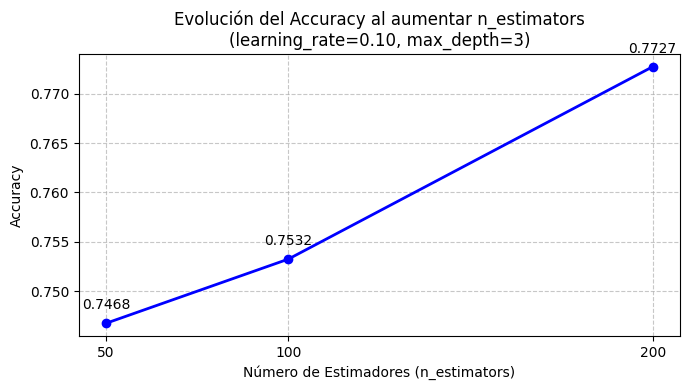

In [291]:

# Filtramos para mantener el entorno constante y ver solo el efecto de n_estimators
filtro_evolucion = df_resultados[
    (df_resultados["learning_rate"] == 0.10) & 
    (df_resultados["max_depth"] == 3)
]

# Ordenamos por n_estimators para que la línea temporal tenga sentido de menor a mayor
filtro_evolucion = filtro_evolucion.sort_values(by="n_estimators")


plt.figure(figsize=(7, 4))
plt.plot(filtro_evolucion["n_estimators"], filtro_evolucion["accuracy"], marker="o", color="b", linestyle='-', linewidth=2)

# Añadimos etiquetas a los puntos para ver el valor exacto
for i, txt in enumerate(filtro_evolucion["accuracy"].round(4)):
    plt.annotate(txt, (filtro_evolucion["n_estimators"].iloc[i], filtro_evolucion["accuracy"].iloc[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel("Número de Estimadores (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Evolución del Accuracy al aumentar n_estimators\n(learning_rate=0.10, max_depth=3)")
plt.xticks([50, 100, 200]) # Ajustamos el eje X a tus valores
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [292]:
# reación y evaluación del mejor modelo de boosting
# En esta celda tomamos la mejor fila de la tabla ordenada (mayor Accuracy)
# y usamos sus hiperparámetros para crear un nuevo GradientBoostingClassifier (best_gbc).
# Entrenamos best_gbc con X_train e y_train y lo evaluamos de nuevo en X_test.
# Mostramos accuracy, precision, recall y F1 para confirmar el rendimiento
# de la mejor configuración encontrada en el experimento.
mejor_fila = df_resultados_sorted.iloc[0]
mejor_fila
best_gbc = GradientBoostingClassifier(
    n_estimators=int(mejor_fila["n_estimators"]),
    learning_rate=mejor_fila["learning_rate"],
    max_depth=int(mejor_fila["max_depth"]),
    random_state=42
)
best_gbc.fit(X_train, y_train.values)

y_pred_best = best_gbc.predict(X_test)

print("Mejor GradientBoosting según accuracy")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, average="binary"))
print("Recall:", recall_score(y_test, y_pred_best, average="binary"))
print("F1:", f1_score(y_test, y_pred_best, average="binary"))

Mejor GradientBoosting según accuracy
Accuracy: 0.7727272727272727
Precision: 0.6938775510204082
Recall: 0.6296296296296297
F1: 0.6601941747572816


### XGBoosting

In [293]:
# Importación de librerías para XGBoost
import pandas as pd
import numpy as np

from xgboost import XGBClassifier  
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carga de los datos procesados
X_train_xg = pd.read_csv("data/raw/X_train_procesado.csv")
X_test_xg  = pd.read_csv("data/raw/X_test_procesado.csv")
y_train_xg = pd.read_csv("data/raw/y_train_procesado.csv").squeeze()
y_test_xg  = pd.read_csv("data/raw/y_test_procesado.csv").squeeze()



print(X_train_xg.shape, X_test_xg.shape, y_train_xg.shape, y_test_xg.shape) #yxg_train.shape, yxg_test.shape)

(614, 6) (154, 6) (614,) (154,)


In [295]:
# Entrenamiento y evaluación del XGBoost base
xgb_base = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",  
    n_jobs=-1
)
xgb_base.fit(X_train_xg, y_train_xg)

y_pred_base_xg = xgb_base.predict(X_test_xg)

acc_base = accuracy_score(y_test_xg, y_pred_base_xg)
prec_base = precision_score(y_test_xg, y_pred_base_xg, average="binary")
rec_base = recall_score(y_test_xg, y_pred_base_xg, average="binary")
f1_base = f1_score(y_test_xg, y_pred_base_xg, average="binary")

print("XGBoost (base)")
print("Accuracy:", acc_base)
print("Precision:", prec_base)
print("Recall:", rec_base)
print("F1:", f1_base)

print("\nClassification report:\n")
print(classification_report(y_test_xg, y_pred_base_xg))

print("\nMatriz de confusión:")
cm_base = confusion_matrix(y_test_xg, y_pred_base_xg)
print(cm_base)

XGBoost (base)
Accuracy: 0.7402597402597403
Precision: 0.6458333333333334
Recall: 0.5740740740740741
F1: 0.6078431372549019

Classification report:

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154


Matriz de confusión:
[[83 17]
 [23 31]]


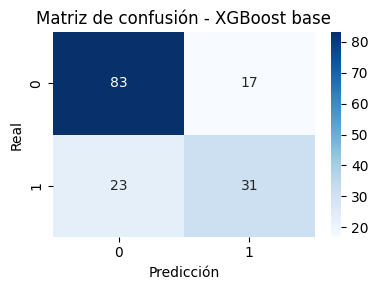

In [296]:
# Matriz de confusión para XGBoost base
plt.figure(figsize=(4, 3))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - XGBoost base")
plt.tight_layout()
plt.show()

In [297]:
# Rejilla de hiperparámetros para XGBoost
resultados = []

param_grid = [
    {"n_estimators": 50,  "learning_rate": 0.1, "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3},
    {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 2},
]

In [298]:
# Entrenamiento de varios modelos XGBoost y recopilación de métricas
for params in param_grid:
    xgb = XGBClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1
    )
    xgb.fit(X_train_xg, y_train_xg)
    yxgb_pred = xgb.predict(X_test_xg)

    acc = accuracy_score(y_test_xg, yxgb_pred)
    prec = precision_score(y_test_xg, yxgb_pred, average="binary")
    rec = recall_score(y_test_xg, yxgb_pred, average="binary")
    f1 = f1_score(y_test_xg, yxgb_pred, average="binary")

    resultados.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,n_estimators,learning_rate,max_depth,accuracy,precision,recall,f1
0,50,0.10,3,0.740260,0.645833,0.574074,0.607843
1,100,0.10,3,0.740260,0.645833,0.574074,0.607843
2,200,0.10,3,0.753247,0.660000,0.611111,0.634615
3,100,0.05,3,0.746753,0.653061,0.592593,0.621359
4,100,0.10,2,0.740260,0.640000,0.592593,0.615385


In [299]:
# Ordenar resultados por accuracy
df_resultados_sortedxg = df_resultados.sort_values(by="accuracy", ascending=False)
print(df_resultados_sortedxg)

   n_estimators  learning_rate  max_depth  accuracy  precision    recall  \
2           200           0.10          3  0.753247   0.660000  0.611111   
3           100           0.05          3  0.746753   0.653061  0.592593   
0            50           0.10          3  0.740260   0.645833  0.574074   
1           100           0.10          3  0.740260   0.645833  0.574074   
4           100           0.10          2  0.740260   0.640000  0.592593   

         f1  
2  0.634615  
3  0.621359  
0  0.607843  
1  0.607843  
4  0.615385  


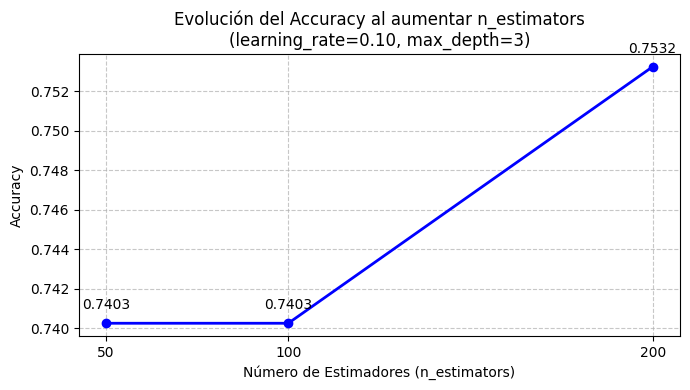

In [300]:
# Filtramos para mantener el entorno constante y ver solo el efecto de n_estimators
filtro_evolucion = df_resultados_sortedxg[
    (df_resultados_sortedxg["learning_rate"] == 0.10) & 
    (df_resultados_sortedxg["max_depth"] == 3)
]

# Ordenamos por n_estimators para que la línea temporal tenga sentido de menor a mayor
filtro_evolucion = filtro_evolucion.sort_values(by="n_estimators")

plt.figure(figsize=(7, 4))
plt.plot(filtro_evolucion["n_estimators"], filtro_evolucion["accuracy"], marker="o", color="b", linestyle='-', linewidth=2)

# Añadimos etiquetas a los puntos para ver el valor exacto
for i, txt in enumerate(filtro_evolucion["accuracy"].round(4)):
    plt.annotate(txt, (filtro_evolucion["n_estimators"].iloc[i], filtro_evolucion["accuracy"].iloc[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel("Número de Estimadores (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Evolución del Accuracy al aumentar n_estimators\n(learning_rate=0.10, max_depth=3)")
plt.xticks([50, 100, 200]) #
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [301]:
# Mejor modelo XGBoost según accuracy
mejor_fila = df_resultados_sortedxg.iloc[0]
mejor_fila

best_xgb = XGBClassifier(
    n_estimators=int(mejor_fila["n_estimators"]),
    learning_rate=mejor_fila["learning_rate"],
    max_depth=int(mejor_fila["max_depth"]),
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1
)
best_xgb.fit(X_train_xg, y_train_xg)

yxg_pred_best = best_xgb.predict(X_test_xg)

print("Mejor XGBoost según accuracy")
print("Accuracy:", accuracy_score(y_test_xg, yxg_pred_best))
print("Precision:", precision_score(y_test_xg, yxg_pred_best, average="binary"))
print("Recall:", recall_score(y_test_xg, yxg_pred_best, average="binary"))
print("F1:", f1_score(y_test_xg, yxg_pred_best, average="binary"))

Mejor XGBoost según accuracy
Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112
F1: 0.6346153846153846


In [302]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones de cada modelo
y_pred_gbc = best_gbc.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test_xg)

metricas = []

for nombre, y_true, y_pred in [
    ("GradientBoosting", y_test, y_pred_gbc),
    ("XGBoost",          y_test_xg, y_pred_xgb)
]:
    metricas.append({
        "modelo": nombre,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="binary"),
        "recall":    recall_score(y_test, y_pred, average="binary"),
        "f1":        f1_score(y_test, y_pred, average="binary")
    })

df_metricas = pd.DataFrame(metricas)
print(df_metricas)

             modelo  accuracy  precision    recall        f1
0  GradientBoosting  0.772727   0.693878  0.629630  0.660194
1           XGBoost  0.753247   0.660000  0.611111  0.634615


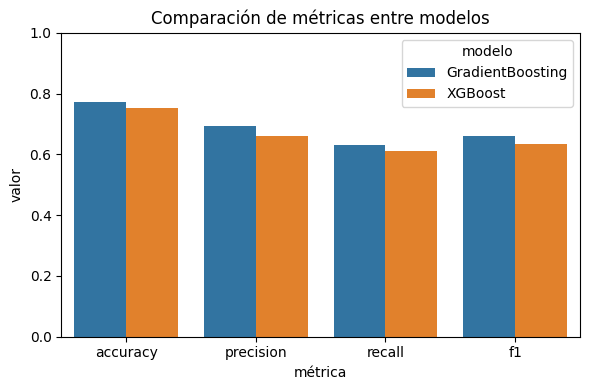

In [303]:
# Pasar a formato largo para graficar fácilmente con seaborn
df_long = df_metricas.melt(id_vars="modelo",
                           value_vars=["accuracy", "precision", "recall", "f1"],
                           var_name="métrica",
                           value_name="valor")

plt.figure(figsize=(6, 4))
sns.barplot(data=df_long, x="métrica", y="valor", hue="modelo")
plt.ylim(0, 1)
plt.title("Comparación de métricas entre modelos")
plt.tight_layout()
plt.show()

### HistGradientBoostingClassifier

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Carga de los datos procesados
X_train_hgb = pd.read_csv("data/raw/X_train_procesado.csv")
X_test_hgb  = pd.read_csv("data/raw/X_test_procesado.csv")
y_train_hgb = pd.read_csv("data/raw/y_train_procesado.csv").squeeze()  # Convertir a Serie si es un DataFrame de una sola columna
y_test_hgb  = pd.read_csv("data/raw/y_test_procesado.csv").squeeze()   # Convertir a Serie si es un DataFrame de una sola columna    



print(X_train_hgb.shape, X_test_hgb.shape, y_train_hgb.shape, y_test_hgb.shape)

# Modelo base
hgb_base = HistGradientBoostingClassifier(random_state=42)
hgb_base.fit(X_train_hgb, y_train_hgb.values)

y_pred_hgb_base = hgb_base.predict(X_test_hgb)

print("HistGradientBoosting (base)")
print("Accuracy:", accuracy_score(y_test_hgb, y_pred_hgb_base))
print("Precision:", precision_score(y_test_hgb, y_pred_hgb_base))
print("Recall:", recall_score(y_test_hgb, y_pred_hgb_base))
print("F1:", f1_score(y_test_hgb, y_pred_hgb_base))

(614, 6) (154, 6) (614,) (154,)
HistGradientBoosting (base)
Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112
F1: 0.6346153846153846


In [305]:
resultados_hgb = []

# Añadimos 'max_iter' para poder graficar la evolución
param_grid_hgb = [
    {"max_depth": 3, "learning_rate": 0.1, "max_iter": 50},
    {"max_depth": 3, "learning_rate": 0.1, "max_iter": 100},
    {"max_depth": 3, "learning_rate": 0.1, "max_iter": 200},
]

for params in param_grid_hgb:
    hgb = HistGradientBoostingClassifier(
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        max_iter=params["max_iter"],
        random_state=42
    )
    hgb.fit(X_train_hgb, y_train_hgb.values.ravel())
    y_pred = hgb.predict(X_test_hgb)

    resultados_hgb.append({
        "max_iter": params["max_iter"], 
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "accuracy": accuracy_score(y_test_hgb, y_pred)
    })

df_resultados_hgb = pd.DataFrame(resultados_hgb)

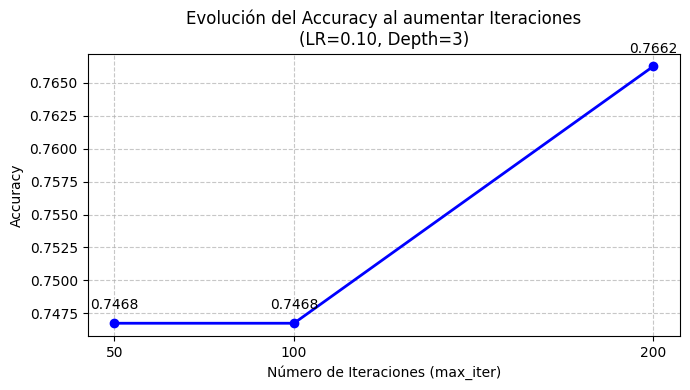

In [306]:
# Filtramos para mantener el entorno constante
filtro_evolucion = df_resultados_hgb[
    (df_resultados_hgb["learning_rate"] == 0.10) & 
    (df_resultados_hgb["max_depth"] == 3)
]

# Ordenamos por max_iter para que la línea tenga sentido
filtro_evolucion = filtro_evolucion.sort_values(by="max_iter")


plt.figure(figsize=(7, 4))
plt.plot(filtro_evolucion["max_iter"], filtro_evolucion["accuracy"], 
         marker="o", color="b", linestyle='-', linewidth=2)

# Etiquetas de valores
for i, txt in enumerate(filtro_evolucion["accuracy"].round(4)):
    plt.annotate(txt, (filtro_evolucion["max_iter"].iloc[i], filtro_evolucion["accuracy"].iloc[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')

df_resultados_hgb_sorted = df_resultados_hgb.sort_values(by="accuracy", ascending=False)
plt.xlabel("Número de Iteraciones (max_iter)")
plt.ylabel("Accuracy")
plt.title("Evolución del Accuracy al aumentar Iteraciones\n(LR=0.10, Depth=3)")
plt.xticks([50, 100, 200]) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [307]:
mejor_hgb_fila = df_resultados_hgb_sorted.iloc[0]

best_hgb = HistGradientBoostingClassifier(
    max_depth=int(mejor_hgb_fila["max_depth"]),
    learning_rate=mejor_hgb_fila["learning_rate"],
    random_state=42
)
best_hgb.fit(X_train_hgb, y_train_hgb.values.ravel())
y_pred_best_hgb = best_hgb.predict(X_test_hgb)

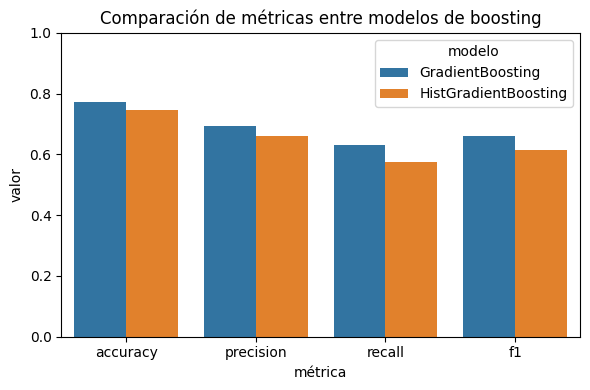

In [308]:
y_pred_gbc = best_gbc.predict(X_test)      # tu mejor GradientBoosting
y_pred_hgb = best_hgb.predict(X_test_hgb)      # tu mejor HistGradientBoosting

metricas = []
for nombre, y_true, y_pred in [
    ("GradientBoosting", y_test, y_pred_gbc),
    ("HistGradientBoosting", y_test_hgb, y_pred_hgb)
]:
    metricas.append({
        "modelo": nombre,
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred)
    })

df_metricas = pd.DataFrame(metricas)
df_long = df_metricas.melt(id_vars="modelo",
                           value_vars=["accuracy", "precision", "recall", "f1"],
                           var_name="métrica",
                           value_name="valor")

plt.figure(figsize=(6, 4))
sns.barplot(data=df_long, x="métrica", y="valor", hue="modelo")
plt.ylim(0, 1)
plt.title("Comparación de métricas entre modelos de boosting")
plt.tight_layout()
plt.show()

In [309]:
import pandas as pd
import matplotlib.pyplot as plt


acc_gbc = accuracy_score(y_test, best_gbc.predict(X_test))
acc_xgb = accuracy_score(y_test, best_xgb.predict(X_test))
acc_hgb = accuracy_score(y_test, best_hgb.predict(X_test))

df_acc = pd.DataFrame({
    "modelo": ["GradientBoosting", "XGBoost", "HistGradientBoosting"],
    "accuracy": [acc_gbc, acc_xgb, acc_hgb]
})

print(df_acc)

                 modelo  accuracy
0      GradientBoosting  0.772727
1               XGBoost  0.753247
2  HistGradientBoosting  0.746753


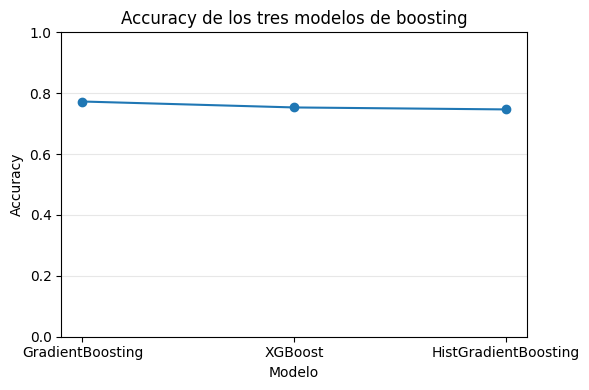

In [310]:
# Gráfico de líneas de accuracy para los tres modelos
plt.figure(figsize=(6, 4))
plt.plot(df_acc["modelo"], df_acc["accuracy"], marker="o")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy de los tres modelos de boosting")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

En este trabajo se han comparado tres algoritmos de boosting —GradientBoostingClassifier, XGBClassifier e HistGradientBoostingClassifier— aplicados a la predicción binaria de diabetes (sí/no) a partir de variables clínicas y demográficas. En todos los casos se ha utilizado el mismo conjunto de entrenamiento y prueba, y se han evaluado las predicciones sobre el conjunto de test mediante accuracy, precision, recall y F1-score.

El modelo que ha mostrado el mejor rendimiento global ha sido el GradientBoostingClassifier. En la configuración óptima seleccionada, alcanza un accuracy en torno al 0,77 y un F1-score cercano a 0,66, lo que indica una buena capacidad para clasificar correctamente a la mayoría de los individuos y un equilibrio razonable entre falsos positivos y falsos negativos. En particular, sus valores de precisión y recall son ligeramente superiores a los de los otros modelos; por ello, resulta el algoritmo más fiable dentro de los ensayos realizados para identificar correctamente a los pacientes con diabetes sin incrementar en exceso las falsas alarmas.

El modelo XGBoost presenta un rendimiento competitivo, pero algo inferior. Su accuracy se sitúa alrededor de 0,75 y su F1-score en torno a 0,63, con valores de precision y recall por debajo de los obtenidos por GradientBoosting. Esto sugiere que, con la rejilla de hiperparámetros probada, XGBoost no llega a explotar todo su potencial en este conjunto de datos concreto y comete algo más de errores, tanto al detectar casos diabéticos como al clasificar sujetos sanos. Aun así, se mantiene dentro de un rango de rendimiento aceptable para tareas de apoyo a la decisión clínica.

El HistGradientBoostingClassifier, por su parte, alcanza niveles de accuracy y F1 muy similares a los de los otros dos algoritmos, con diferencias numéricas pequeñas. Su principal ventaja radica en la eficiencia computacional y la buena escalabilidad, lo que lo convierte en una alternativa interesante cuando se trabaja con volúmenes de datos mayores o se requiere entrenar modelos con frecuencia. En este problema concreto, sin embargo, no supera de forma clara a GradientBoosting en términos de exactitud de clasificación.

En conjunto, los resultados muestran que los métodos de boosting constituyen una herramienta adecuada para la predicción de diabetes, ofreciendo niveles de accuracy de entre el 75 % y el 77 % en el conjunto de prueba. Dentro de las configuraciones ensayadas, el modelo de GradientBoostingClassifier se posiciona como la opción preferible al proporcionar el mejor compromiso entre precisión, recall y F1-score. XGBoost e HistGradientBoosting se mantienen como alternativas sólidas, especialmente valiosas si se amplía la búsqueda de hiperparámetros o se prioriza la eficiencia computacional; no obstante, con los ajustes actuales, no logran mejorar el desempeño alcanzado por GradientBoosting.
